# Detecting the anomalous activity of a ship’s engine
# Technical Stack

Python | pandas | NumPy | scikit-learn | matplotlib | seaborn | PCA | Isolation Forest | One-Class SVM | Outlier Detection | Jupyter Notebook

#Introduction

This project investigates anomaly detection methods using multivariate sensor data from ship engine systems. The work applies machine learning and statistical techniques in Python to identify abnormal operational behaviour within complex engineering datasets.

#Business Context

Modern industrial and engineering systems generate large volumes of sensor data that can be used to monitor operational performance and detect faults early. Effective anomaly detection can support predictive maintenance, reduce downtime, and improve system reliability in data-intensive environments.

#Objectives
* Explore and preprocess high-dimensional sensor data
* Detect outliers using statistical methods
* Apply dimensionality reduction using PCA
* Implement anomaly detection models including One-Class SVM and Isolation Forest
* Compare model performance and interpret detected anomalies
* Visualise patterns and anomalies within the dataset

> **Disclaimer**
>
> Please note that although a real-life data set was provided, the business context in this project is fictitious. Any resemblance to companies and persons (living or dead) is coincidental. The course designers and hosts assume no responsibility or liability for any errors or omissions in the content of the business context and data sets. The information in the data sets is provided on an 'as is' basis with no guarantees of completeness, accuracy, usefulness, or timeliness.

<br></br>


# EDA

In [ ]:
# URL to import data set from GitHub.
# url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'
df = pd.read_csv(url)

# Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Display the shape of the dataset
print("\nShape of the dataset:")
print(df.shape)

print("\n Info on Database:")
# Check missing values
print(df.isnull().sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

First 5 rows of the dataset:
   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         682          2.391656       4.617196          2.848982   
1         605          5.466877       6.424361          5.727520   
2         658          3.434232       3.680896          1.678708   
3         749          2.094656       7.120927          1.639670   
4         676          3.538228       5.956472          3.225336   

   lub oil temp  Coolant temp  
0     76.272417     69.884609  
1     73.222679     74.907314  
2     88.089916     78.704806  
3     77.661625     82.386700  
4     75.226352     67.153220  

Shape of the dataset:
(19535, 6)

 Info on Database:
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64
Duplicate rows: 0


My main goal to start with was to clarify that there are no missing elements in the database, and that there are no duplications. So far it looks good. The data has 6 features, and 19535 rows, all numerical values.

Next I want to visualise the data to look for obvious anomalies/outliers with a boxplot.

         Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
count  19535.000000      19535.000000   19535.000000      19535.000000   
mean     791.239263          3.303775       6.655615          2.335369   
std      267.611193          1.021643       2.761021          1.036382   
min       61.000000          0.003384       0.003187          0.002483   
25%      593.000000          2.518815       4.916886          1.600466   
50%      746.000000          3.162035       6.201720          2.166883   
75%      934.000000          4.055272       7.744973          2.848840   
max     2239.000000          7.265566      21.138326          7.478505   

       lub oil temp  Coolant temp  
count  19535.000000  19535.000000  
mean      77.643420     78.427433  
std        3.110984      6.206749  
min       71.321974     61.673325  
25%       75.725990     73.895421  
50%       76.817350     78.346662  
75%       78.071691     82.915411  
max       89.580796    195.527912  


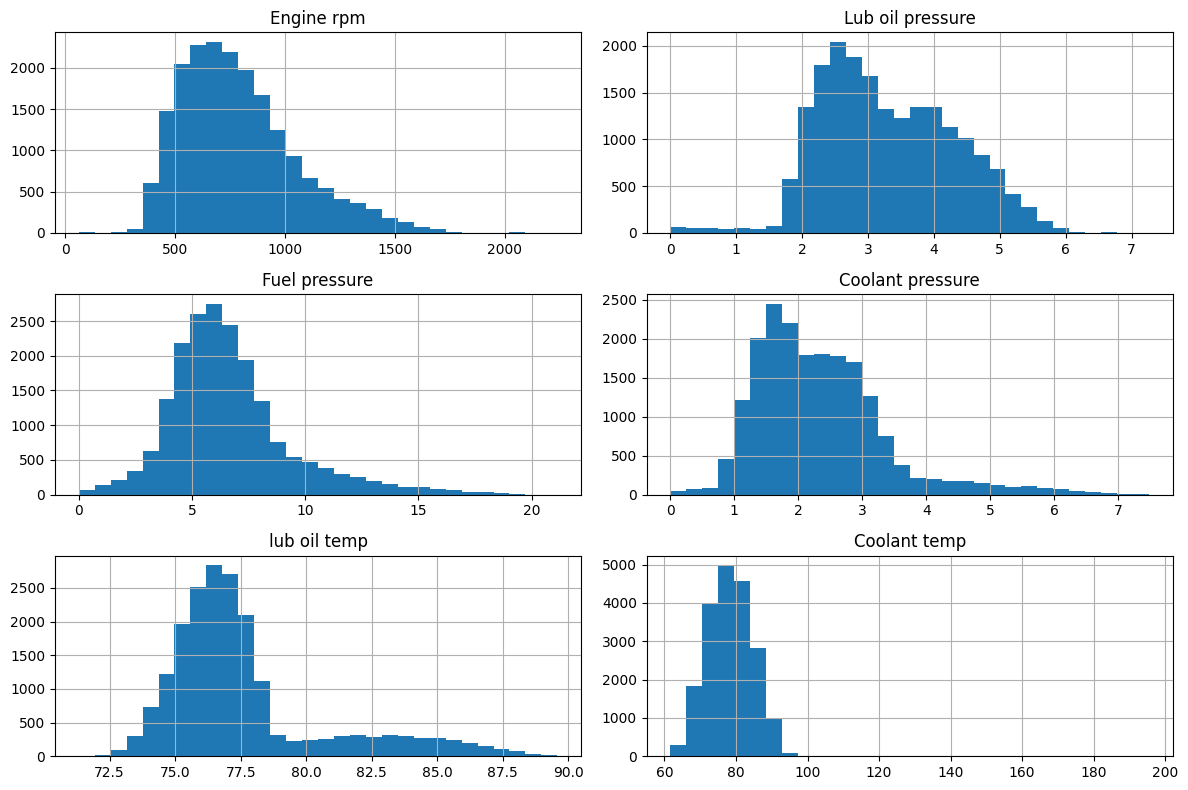

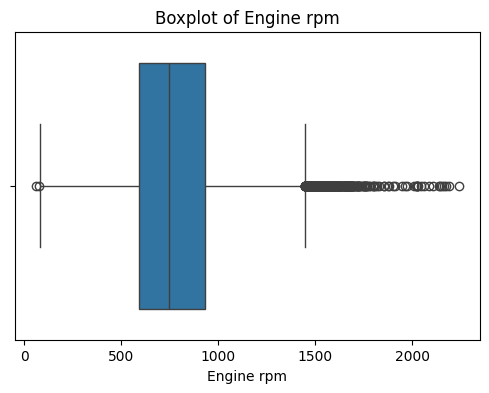

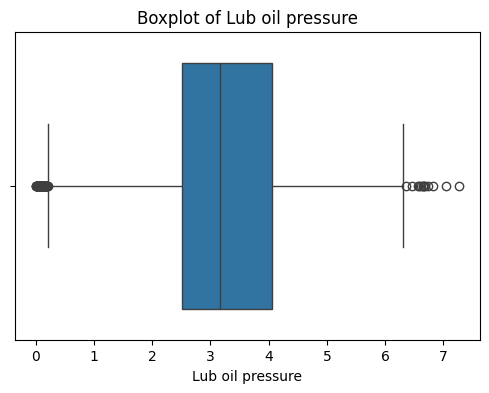

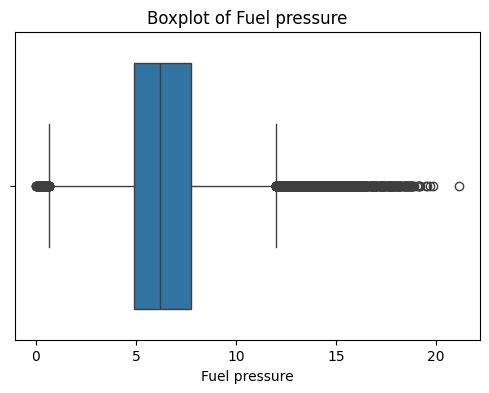

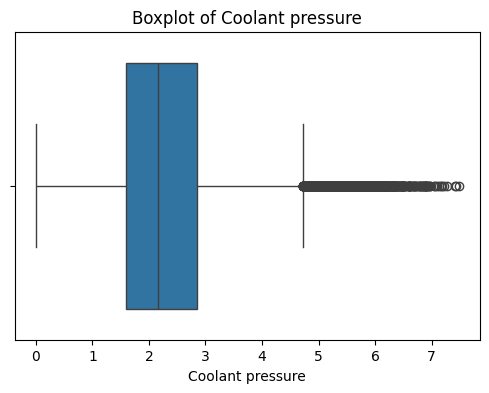

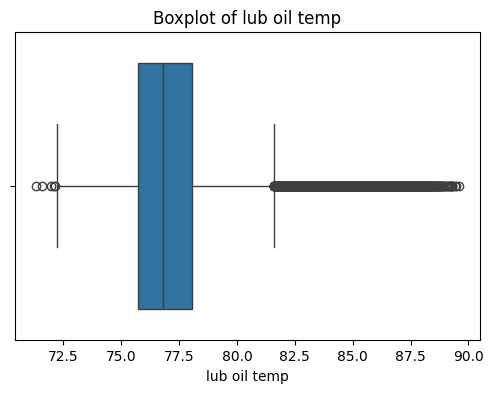

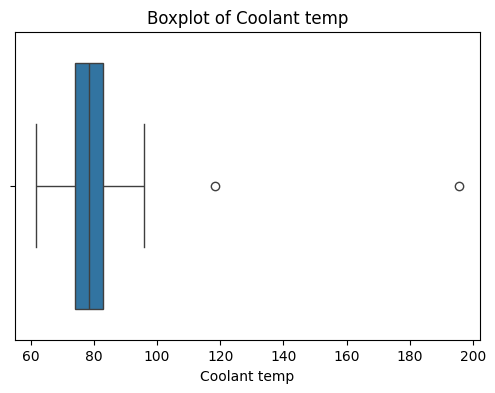

In [ ]:
# Descriptive statistics
print(df.describe())

# Histograms
df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

# Create individual boxplots for each feature
for column in df.columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

I can see from the visualisation that the Lube Oil Temp and Coolant temp are right skewed in distribution. Where the values skew far right this could signify anomalies but distribution overall is relatively normal.

**Also noted:**

Coolant temp max = 195 vs median approx 78

Fuel pressure also has a wide max (21 vs median approx 6)

# IQR
Next I will calculate the IQR

In [ ]:
# Create a copy to work on
df_iqr = df.copy()

# Loop through each column
for column in df.columns:

    # Calculate Q1 and Q3
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Create outlier flag column
    df_iqr[column + '_outlier'] = ((df[column] < lower) | (df[column] > upper)).astype(int)

    # Count outliers per feature
    outlier_counts = df_iqr.filter(like='_outlier').sum().sort_values(ascending=False)
print("\n Outlier counts for each feature: ")
print(outlier_counts)


 Outlier counts for each feature: 
lub oil temp_outlier        2617
Fuel pressure_outlier       1135
Coolant pressure_outlier     785
Engine rpm_outlier           464
Lub oil pressure_outlier      66
Coolant temp_outlier           2
dtype: int64


There are significan outliers for lub oil temp and fuel pressure. I will quickly now calculate the percentage of outliers for each feature to see if they fall between the 1 and 5% expected range.

In [ ]:
# Total number of rows of the whole data set (the 100%)
total_rows = len(df_iqr)

# Calculate percentage of outliers per feature (note: I used '_outlier' becasue that is the difference in column/feature name I added above)
outlier_percent = (df_iqr.filter(like='_outlier').sum() / total_rows) * 100

# Sort for readability
outlier_percent = outlier_percent.sort_values(ascending=False)

print(outlier_percent)

lub oil temp_outlier        13.396468
Fuel pressure_outlier        5.810084
Coolant pressure_outlier     4.018428
Engine rpm_outlier           2.375224
Lub oil pressure_outlier     0.337855
Coolant temp_outlier         0.010238
dtype: float64


The output reads interestingly;

*   lub oil temp_outlier        13.396468  this is too high for anomalies
*   Fuel pressure_outlier        5.810084  this is too high for anomalies
*   Coolant pressure_outlier     4.018428  this is within the 1-5% range
*   Engine rpm_outlier           2.375224  this is within the 1-5% range
*   Lub oil pressure_outlier     0.337855  this is too low
*   Coolant temp_outlier         0.010238  this is too low


This tells me that I need to adjust the measurement for how I define an anomaly for the top two. They might just naturally be that way in how they are skewed (I don't know enough about engines to know for sure). It could be noise, so now I need to look at Rows to see what patterns emerge with the outliers, and if they sync.

Now I want to see how many outliers a Row needs to be considered anomalous. I will try different thresholds to see what we find.

In [ ]:
# Count how many features are outliers per row
df_iqr['outlier_count'] = df_iqr.filter(like='_outlier').sum(axis=1)

# Test different thresholds, 'Does this row have at least i outlier features?'
for i in range(1, 7):
    percentage = (df_iqr['outlier_count'] >= i).mean() * 100  #calcs % of rows that meet the condition (that there are i or more outliers in the row) prompted from ChatGPT
    print(f"{i}+ outlier features: {percentage:.2f}%") #Used format string to make it easier to read the output, .2 means to 2 decimal places

1+ outlier features: 23.73%
2+ outlier features: 2.16%
3+ outlier features: 0.06%
4+ outlier features: 0.00%
5+ outlier features: 0.00%
6+ outlier features: 0.00%


From this output I feel like 1 outlier feature isn't enough to really find an anomalous Row, it is likely just a lot of noise. Looking at the output it seems like 2 features sits nicely between 1 and 5% which is what we are looking for as a true anomaly.

Now I am going to classify rows as being anomalous based on if they meet the criteria of having at least 2 outlier features within the row.

In [ ]:
# Final anomaly classification
df_iqr['anomaly_iqr'] = (df_iqr['outlier_count'] >= 2).astype(int)

# Check percentage of rows that are classified to see if they match the above For loop's output
print((df_iqr['anomaly_iqr'].mean()) * 100)

2.160225236754543


It looks correct, and matches the % from the For loop, so I will now separate the rows that are potentially anomalous and take a look at them.

In [ ]:
# Filter anomalous rows
anomalies = df_iqr[df_iqr['anomaly_iqr'] == 1]

# View first few
print("Anomaly Rows")
display(anomalies.head())

#take a look as a whole
print('\n Shape: ',anomalies.shape, '\n')

#Compare with 'normal' rows to see how data compares
normal = df_iqr[df_iqr['anomaly_iqr'] == 0]
print("Normal Rows")
display(normal.head())

Anomaly Rows


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,outlier_count,anomaly_iqr
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,1,0,0,0,1,0,2,1
122,1454,2.063374,6.168260,1.260121,83.372256,82.718247,1,0,0,0,1,0,2,1
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,0,0,1,0,1,0,2,1
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,1,0,0,0,1,0,2,1
148,1494,2.443220,3.548139,1.953403,82.234541,83.953914,1,0,0,0,1,0,2,1



 Shape:  (422, 14) 

Normal Rows


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,outlier_count,anomaly_iqr
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1,0
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1,0
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0,0


From what I can see there is a pattern of the lub oil temp being anomalous and it is pared either with very high engine RPM or very high fuel pressure. This is something I will look for later.

# Looking deeper at IQR
Next I want to do a broad investigation, then go more focused, then see if this relationship (or perhaps others) exist.

I'll start with anomalous vs normal row distributions to visualise and see if there is anything interesting. I'll use histograms for that.

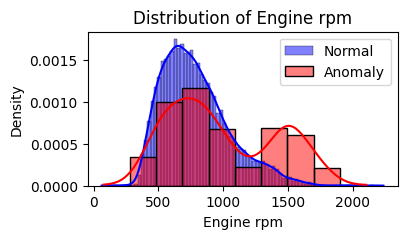

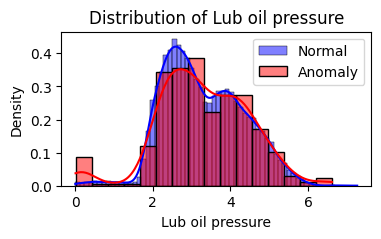

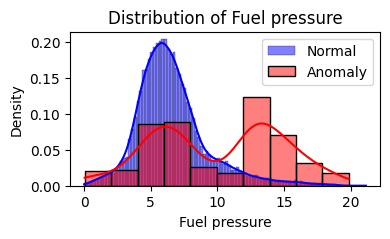

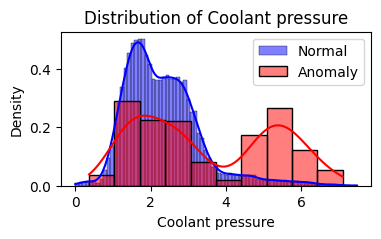

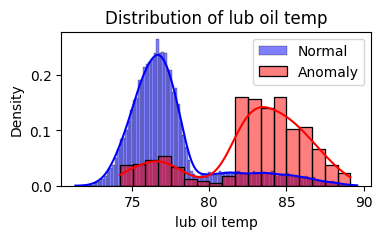

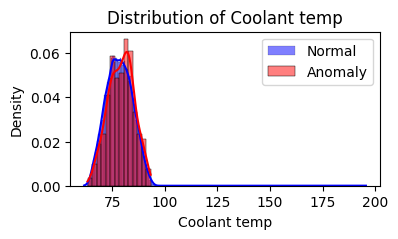

In [ ]:
# Loop through each original feature
for column in df.columns:
    plt.figure(figsize=(4,2))

    # Plot normal vs anomaly
    sns.histplot(df_iqr[df_iqr['anomaly_iqr'] == 0][column],
                 color='blue', label='Normal', kde=True, stat='density')

    sns.histplot(df_iqr[df_iqr['anomaly_iqr'] == 1][column],
                 color='red', label='Anomaly', kde=True, stat='density')

    plt.title(f'Distribution of {column}')
    plt.legend()
    plt.show()

This is very interesting, as I can see that the anomalies are mostly in the tails of the distributions. Lub oil temp has a very big difference in distribution that I feel shows a strong anomalous pattern. I can predict now that it is probably going to be the driver of finding anomalies.

The issue is that some features overlap in normal vs anom, and this tells me that these are not going to be as useful for detection of anomalies.

The general observation is that anomalies tend to occur in the extreme upper ranges of features such as engine RPM, fuel pressure, coolant pressure, and lub oil temp.

I wil now do Box Plots to see if this pattern continues.

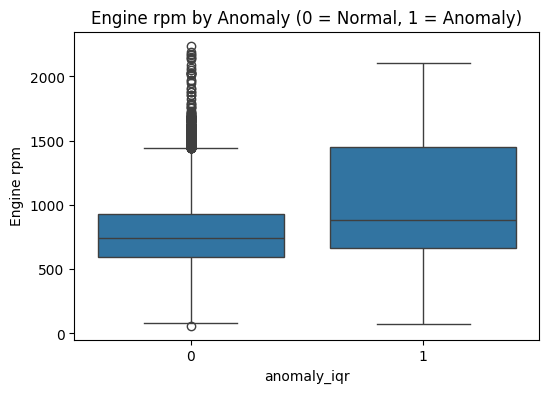

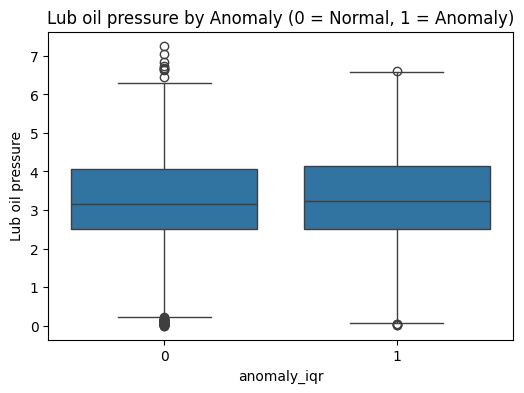

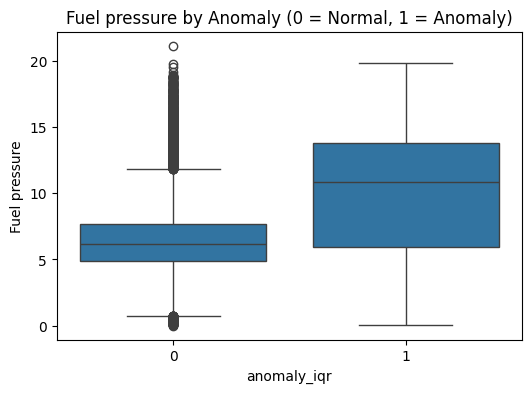

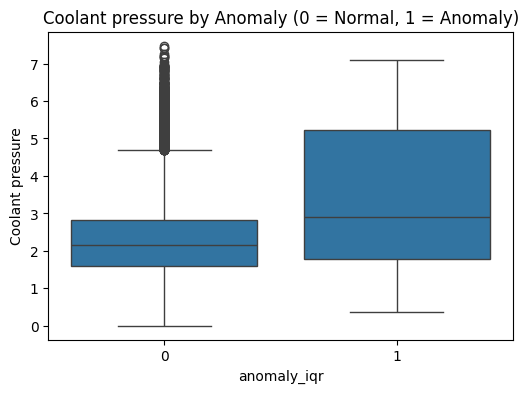

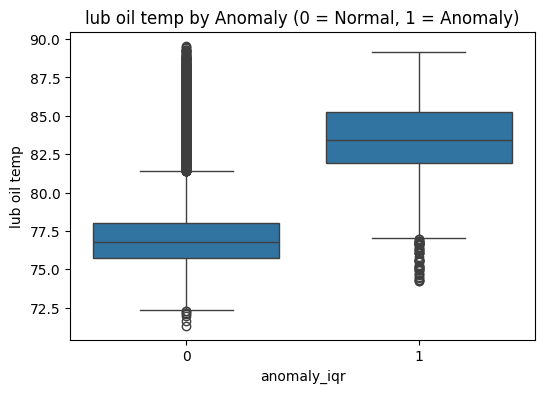

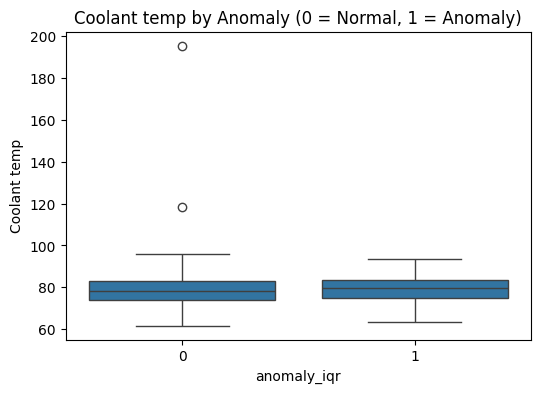

In [ ]:
# Loop through each original feature
for column in df.columns:
    plt.figure(figsize=(6,4))

    sns.boxplot(x='anomaly_iqr', y=column, data=df_iqr)

    plt.title(f'{column} by Anomaly (0 = Normal, 1 = Anomaly)')
    plt.show()

From this visualisation I can also see that Coolant Temp is not very useful in detecting anomalies.

Lub Oil temp has a distict difference, almost in two separate groups with little distribution crossover as seen in the Histograms. Coolant pressure has a wide spread of distribution in the IQR but the median is not too far between norm and anom. Fuel pressure has a clear separation too.

I now feel that lubrication oil temperature and fuel pressure are the strongest indicators of an anomaly.

Next: I will compare these features with Engine RPM and each other to learn more.

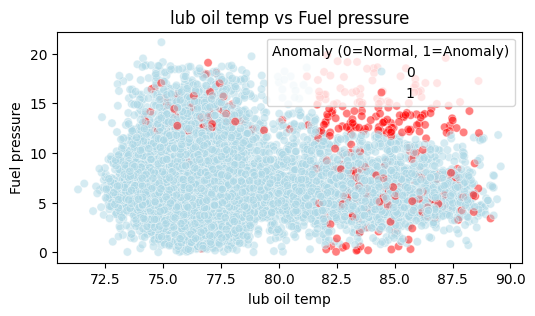

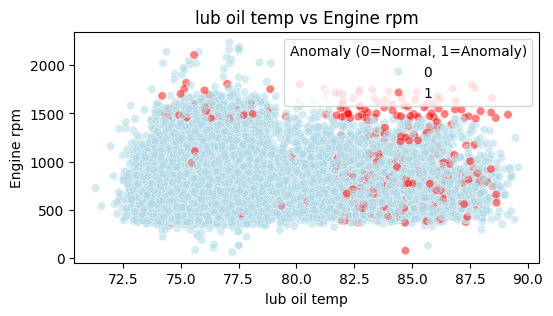

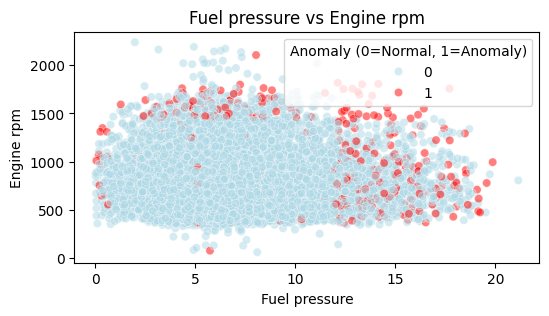

In [ ]:
# Define feature pairs
pairs = [
    ('lub oil temp', 'Fuel pressure'),
    ('lub oil temp', 'Engine rpm'),
    ('Fuel pressure', 'Engine rpm')
]

# Plot each pair
for x, y in pairs:
    plt.figure(figsize=(6,3))

    sns.scatterplot(
        data=df_iqr,
        x=x,
        y=y,
        hue='anomaly_iqr',
        palette={0: 'lightblue', 1: 'red'},
        alpha=0.5
    )

    plt.title(f'{x} vs {y}')
    plt.legend(title='Anomaly (0=Normal, 1=Anomaly)')
    plt.show()

Fuel pressure and RPM have a lot of overlap here, so this suggests it has 'lower discriminatory power'

Lub oil Pressure vs fuel pressure has a clear cluster when both are high, so I think this will still be the strongest relationship indicator.

# Standardisation
I feel that now we are ready for applying PCA to IQR, so I will standardise the data due to the differences between RPM and Lub oil pressure, and then run PCA. Larger scales might dominate the PCA so it is important to do this first.

In [ ]:
# Import the required library.
from sklearn.preprocessing import StandardScaler

# Specify the input features.
# I am using only the original features (not the outlier columns I created).
X = df.copy()

# Create a StandardScaler object.
scaler = StandardScaler()

# Fit and transform the data.
X_scaled = scaler.fit_transform(X)

# View the shape of the scaled data.
print(X_scaled.shape)

(19535, 6)


Output looks correct with 6 features and 19535 rows as expected.
# PCA (applied to IQR)

 Now to move to PCA to reduce our 6 features into 2 dimensions rather than 6. This should allow me to see patterns more easily, but it will still not allow me to detect anomalies yet.

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA()

# Fit PCA on scaled data
pca.fit(X_scaled)

# Get explained variance
explained_variance = pca.explained_variance_ratio_

# Create DataFrame
explained_variance_table = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Explained Variance': explained_variance
})

# Round for readability to 3sf
explained_variance_table = explained_variance_table.round(3)

# Display table
display(explained_variance_table)

,Component,Explained Variance
0,PC1,0.190
1,PC2,0.177
2,PC3,0.171
3,PC4,0.157
4,PC5,0.156
5,PC6,0.149


Output suggests variance is equally spread, so no individual feature dominates. Components 1 and 2 account for 36% of the variance. Not very big but usable.

In [ ]:
# Calculate cumulative explained variance together for a table
cumulative_variance = explained_variance.cumsum()

# Create DataFrame
pca_variance_table = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(cumulative_variance))],
    'Explained Variance': explained_variance,
    'Cumulative Variance': cumulative_variance
})

# Display table
display(pca_variance_table)

,Component,Explained Variance,Cumulative Variance
0,PC1,0.189948,0.189948
1,PC2,0.176930,0.366878
2,PC3,0.170714,0.537592
3,PC4,0.156753,0.694345
4,PC5,0.156464,0.850809
5,PC6,0.149191,1.000000


After a bit of research, as I wasn't quite sure where to go next, I looked at cumulative variance. And from the output I noted that although four components capture approx 70% of the variance, two components would have to be selected for visualisation purposes to enable interpretation of anomaly patterns in a 2D space (which is what PCA ultimately is for).

,PC1,PC2,anomaly_iqr
0,-0.557362,-0.906512,0
1,-2.177170,-1.201538,0
2,2.051806,1.039581,0
3,0.744375,-0.501140,0
4,-1.629821,-0.473906,0


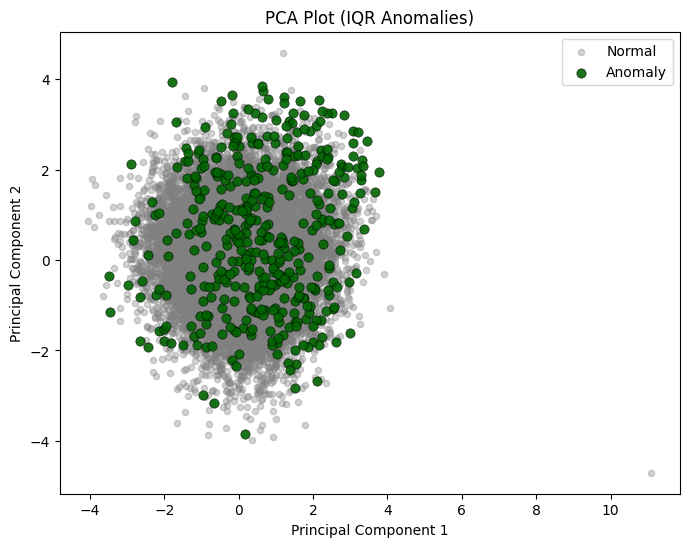

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object with 2 components
pca = PCA(n_components=2)

# Fit and transform the scaled data
X_pca = pca.fit_transform(X_scaled)

# Convert to DataFrame for easier handling
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Add anomaly labels (IQR)
pca_df['anomaly_iqr'] = df_iqr['anomaly_iqr'].values

# View first few rows
display(pca_df.head())

######################## Below is the visualisation part of the code.

# Plot PCA results with improved clarity
plt.figure(figsize=(8, 6))

# Plot normal points first (background)
plt.scatter(
    pca_df[pca_df['anomaly_iqr'] == 0]['PC1'],
    pca_df[pca_df['anomaly_iqr'] == 0]['PC2'],
    c='grey',
    alpha=0.35,
    s=20,
    label='Normal'
)

# Plot anomalies on top (foreground)
plt.scatter(
    pca_df[pca_df['anomaly_iqr'] == 1]['PC1'],
    pca_df[pca_df['anomaly_iqr'] == 1]['PC2'],
    c='darkgreen',
    alpha=0.9,
    s=45,
    edgecolor='black',
    linewidth=0.4,
    label='Anomaly'
)

plt.title('PCA Plot (IQR Anomalies)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

This output clearly shows that my earlier analysis provided more insight. This shows that there is a lot of overlap between the normal and anomalous data. This tells me that anomalies don't necessasrily form distinct clusters, and from a more human level might tell me why detecting engine anomalies has been hard for the client in the first place.


# ML methods
# SVM
I feel that now with this visualisation complete, it is time to use ML tools, so I will start by applying SVM to the standardised DF.
SVM needs a NU value, which I will plug in as approximately 2.16 from the estimation I made earlier based on 2 or more anomalies per Row within the data set. Along with this I'll try a variety of NU and Gamma values to see what % of results are identified as potential anomalies.

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.svm import OneClassSVM

# Use scaled data (important: keep using the standardised data)
X_svm = X_scaled

# Define parameter values to test, 0.02 is where I wanted to start from
nu_values = [0.02, 0.05, 0.1]
gamma_values = [0.01, 0.1, 0.5, 1]

# Create empty list to store results
results = []

# Test all combinations of nu and gamma
for nu in nu_values:
    for gamma in gamma_values:

        # Create model
        model = OneClassSVM(kernel='rbf', gamma=gamma, nu=nu)

        # Fit model
        model.fit(X_svm)

        # Predict anomalies (1 = normal, -1 = anomaly)
        y_pred = model.predict(X_svm)

        # Convert to 0 (normal) and 1 (anomaly)
        y_pred = (y_pred == -1).astype(int)

        # Calculate anomaly count and percentage
        anomaly_count = y_pred.sum()
        anomaly_percentage = y_pred.mean() * 100

        # Store results
        results.append({
            'nu': nu,
            'gamma': gamma,
            'anomaly_count': anomaly_count,
            'anomaly_percentage': round(anomaly_percentage, 2)
        })

# Convert results to DataFrame
svm_results = pd.DataFrame(results)

# View results table
display(svm_results)


,nu,gamma,anomaly_count,anomaly_percentage
0,0.02,0.01,390,2.00
1,0.02,0.10,392,2.01
2,0.02,0.50,627,3.21
3,0.02,1.00,1855,9.50
4,0.05,0.01,977,5.00
5,0.05,0.10,978,5.01
6,0.05,0.50,1043,5.34
7,0.05,1.00,1861,9.53
8,0.10,0.01,1953,10.00
9,0.10,0.10,1951,9.99


Here I can see that when NU was set to 0.02 (closest to my estimate) it returns 3.21 which, out of the results, is the most comfortably located value between the 1-5% anomaly threshold. I will use 0.02 as the NU going forward.
I chose to keep Gamma at 0.5.
This is mainly because lower gamma values produced a smoother decision boundary, while higher gamma values increase sensitivity to local variation. A mid-range gamma value was used because it produced an anomaly rate within the expected range without creating an overly fragmented anomaly pattern.

In [ ]:
# Create final SVM model
svm_model = OneClassSVM(kernel='rbf', gamma=0.5, nu=0.02)

# Fit the model
svm_model.fit(X_svm)

# Predict anomalies
y_svm = svm_model.predict(X_svm)

# Convert to 0 (normal) and 1 (anomaly)
y_svm = (y_svm == -1).astype(int)

# Add results to DataFrame (important)
df_iqr['anomaly_svm'] = y_svm

# Check percentage
print((df_iqr['anomaly_svm'].mean()) * 100)

3.2096237522395703


# PCA (Applied to SVM)
Now I have my anomaly_svm result I want to visualise it, so I will use the same code I used for the PCA before to see what is happening.

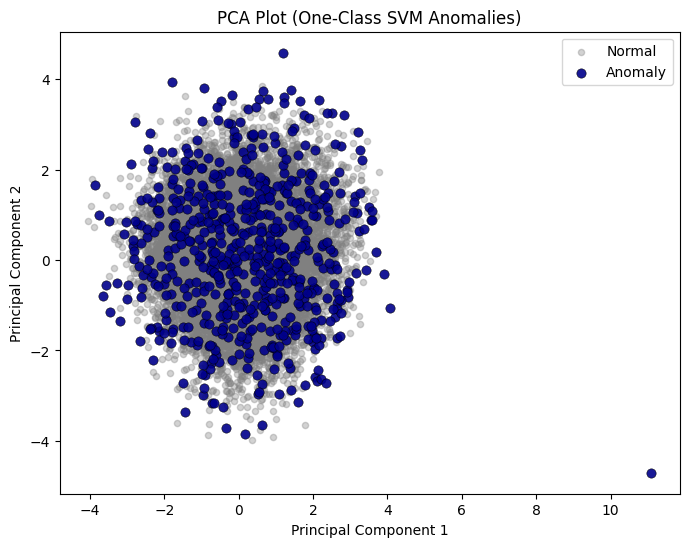

In [ ]:
# Add SVM anomaly labels to the PCA DataFrame
pca_df['anomaly_svm'] = df_iqr['anomaly_svm'].values

# Plot PCA results with anomaly highlighting
plt.figure(figsize=(8, 6))

# Plot normal points first
plt.scatter(
    pca_df[pca_df['anomaly_svm'] == 0]['PC1'],
    pca_df[pca_df['anomaly_svm'] == 0]['PC2'],
    c='grey',
    alpha=0.35,
    s=20,
    label='Normal'
)

# Plot anomalies on top
plt.scatter(
    pca_df[pca_df['anomaly_svm'] == 1]['PC1'],
    pca_df[pca_df['anomaly_svm'] == 1]['PC2'],
    c='darkblue',
    alpha=0.9,
    s=45,
    edgecolor='black',
    linewidth=0.4,
    label='Anomaly'
)

plt.title('PCA Plot (One-Class SVM Anomalies)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()



Interestingly the SVM anomalies look more distributed than the PCA visualisation showed. But then this is expected as SVM doesn't look at individual features. I struggled to put this into words, but I would say this shows that SVM allows me to see that anomalies are spread around around the edges of the data.

#Initial comp of IQR and SVM
I am curious how there might be overlap and 'agreement' between IQR and SVM, so  I want to see where the anomalies are agreed upon between them. This should be simple enough to sum the rows and use boolean logic to compare the svm set and iqr sets in the DF.

In [ ]:
# Create comparison columns
both = ((df_iqr['anomaly_iqr'] == 1) & (df_iqr['anomaly_svm'] == 1)).sum()
iqr_only = ((df_iqr['anomaly_iqr'] == 1) & (df_iqr['anomaly_svm'] == 0)).sum()
svm_only = ((df_iqr['anomaly_iqr'] == 0) & (df_iqr['anomaly_svm'] == 1)).sum()

# Total anomalies (for reference)
total_iqr = df_iqr['anomaly_iqr'].sum()
total_svm = df_iqr['anomaly_svm'].sum()

print(f"Both methods: {both}")
print(f"IQR only: {iqr_only}")
print(f"SVM only: {svm_only}")
print(f"Total IQR anomalies: {total_iqr}")
print(f"Total SVM anomalies: {total_svm}")

Both methods: 120
IQR only: 302
SVM only: 507
Total IQR anomalies: 422
Total SVM anomalies: 627


This tells me something interesting: I know that IQR is univariate (feature-based) and SVM is multivariate (pattern-based)

So SVM is probably finding the interesting combinations of feature anomalies and not just the extremes/outliers.

In [ ]:
# Filter SVM-only anomalies
svm_only_df = df_iqr[(df_iqr['anomaly_svm'] == 1) & (df_iqr['anomaly_iqr'] == 0)]

# View sample
display(svm_only_df.head())

# Check how many
print(svm_only_df.shape)

#Now I need to see the IQR only anomalies
# Filter IQR-only anomalies
iqr_only_df = df_iqr[(df_iqr['anomaly_iqr'] == 1) & (df_iqr['anomaly_svm'] == 0)]

display(iqr_only_df.head())

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,outlier_count,anomaly_iqr,anomaly_svm
17,1312,5.963439,7.563578,5.931953,77.738876,88.661972,0,0,0,1,0,0,1,0,1
149,1193,3.669258,7.845989,1.229372,85.322621,67.009104,0,0,0,0,1,0,1,0,1
189,252,2.759883,11.209682,2.362125,75.691300,72.197108,0,0,0,0,0,0,0,0,1
244,936,4.305496,4.956328,3.000931,75.204754,93.890816,0,0,0,0,0,0,0,0,1
245,848,4.105940,4.408648,2.524463,78.278250,65.001209,0,0,0,0,0,0,0,0,1


(507, 15)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,outlier_count,anomaly_iqr,anomaly_svm
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,1,0,0,0,1,0,2,1,0
122,1454,2.063374,6.168260,1.260121,83.372256,82.718247,1,0,0,0,1,0,2,1,0
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,0,0,1,0,1,0,2,1,0
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,1,0,0,0,1,0,2,1,0
148,1494,2.443220,3.548139,1.953403,82.234541,83.953914,1,0,0,0,1,0,2,1,0


This confirms something I wondered, as to whether SVM was looking at the extreme values that IQR was, and as we can see there are plenty of flags for rows that have 0 or 1 outliers, showign that it has found odd combinations of the features. This explains why the IQR and SVM matching anomalies are more limited than I had imagined.

# Isolation Forest (ISO)
The Isolation Forest tool is good at dealing with both, so I will apply this next and see if I am able to find the balance that is missing between IQR and SVM. I will try a variety of contamination values and tree values to see which parameters work best.

In [ ]:
# Import required libraries
import pandas as pd
from sklearn.ensemble import IsolationForest

# Define contamination values and number of trees to try
contamination_values = [0.01, 0.02, 0.03, 0.04, 0.05]
tree_values = [50, 100, 200]

# Store results
results = []

# Loop through all combinations
for contamination in contamination_values:
    for trees in tree_values:

        # Create model
        iso_model = IsolationForest(
            contamination=contamination,
            n_estimators=trees,
            random_state=42
        )

        # Fit model
        iso_model.fit(X_scaled)

        # Predict anomalies
        y_iso = iso_model.predict(X_scaled)

        # Convert to 0 (normal) and 1 (anomaly)
        y_iso = (y_iso == -1).astype(int)

        # Calculate results
        anomaly_count = y_iso.sum()
        anomaly_percentage = y_iso.mean() * 100

        # Store results
        results.append({
            'contamination': contamination,
            'trees': trees,
            'anomaly_count': anomaly_count,
            'anomaly_percentage': round(anomaly_percentage, 2)
        })

# Convert to DataFrame
iso_results = pd.DataFrame(results)

# Display results
display(iso_results)

,contamination,n_estimators,anomaly_count,anomaly_percentage
0,0.01,50,196,1.0
1,0.01,100,196,1.0
2,0.01,200,196,1.0
3,0.02,50,391,2.0
4,0.02,100,391,2.0
5,0.02,200,391,2.0
6,0.03,50,587,3.0
7,0.03,100,587,3.0
8,0.03,200,587,3.0
9,0.04,50,782,4.0


This is good for an output as the anomaly output shows that the Isolation FOrest, SVM, and IQR are pointing to roughly the same anomaly rate around 2-3% so long as the ISO forest uses around a 0.03 contamination and 200 trees (used for more stability).

#PCA (Applied to ISO)

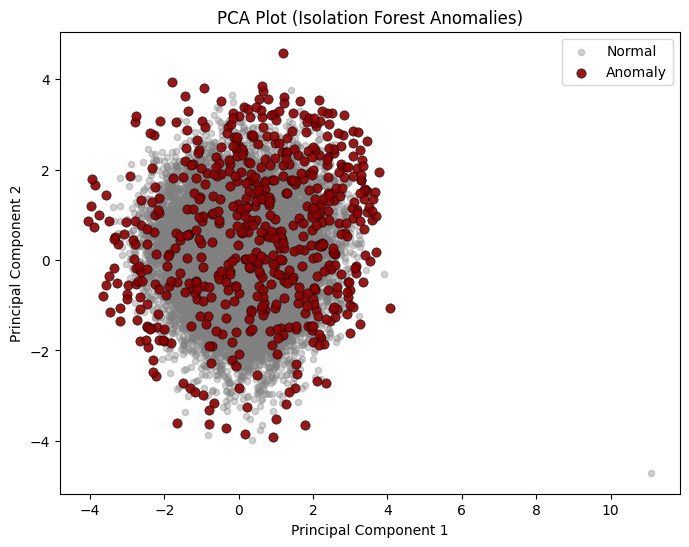

In [ ]:
# Create Isolation Forest model with chosen settings
iso_model = IsolationForest(
    contamination=0.03,
    n_estimators=200,
    random_state=42
)

# Fit model
iso_model.fit(X_scaled)

# Predict anomalies
y_iso = iso_model.predict(X_scaled)

# Convert to 0 (normal) and 1 (anomaly)
y_iso = (y_iso == -1).astype(int)

# Overwrite anomaly column (keep naming consistent)
df_iqr['anomaly_iso'] = y_iso

# Add to PCA DataFrame
pca_df['anomaly_iso'] = df_iqr['anomaly_iso'].values


# Plot PCA results
plt.figure(figsize=(8, 6))

# Normal points
plt.scatter(
    pca_df[pca_df['anomaly_iso'] == 0]['PC1'],
    pca_df[pca_df['anomaly_iso'] == 0]['PC2'],
    c='grey',
    alpha=0.35,
    s=20,
    label='Normal'
)

# Anomalies
plt.scatter(
    pca_df[pca_df['anomaly_iso'] == 1]['PC1'],
    pca_df[pca_df['anomaly_iso'] == 1]['PC2'],
    c='darkred',
    alpha=0.9,
    s=45,
    edgecolor='black',
    linewidth=0.4,
    label='Anomaly'
)

plt.title('PCA Plot (Isolation Forest Anomalies)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

This visualisation shows that the anomaly points are further from the central cluster and are less overlaped with the normal points compared to the previous scatter plots. It is supposed to be better at idenftifying these points that are indeed further away and not within that central space.

Interestingly, compared to the previous approach with SVM the outlier that sits above 10 on PC1 is recorded as normal and not an anomaly.

In [ ]:
# Filter Isolation Forest–only anomalies
iso_only_df = df_iqr[(df_iqr['anomaly_iso'] == 1) & (df_iqr['anomaly_svm'] == 0) & (df_iqr['anomaly_iqr'] == 0)]

# View sample
display(iso_only_df.head())

# Check how many
print(iso_only_df.shape)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,outlier_count,anomaly_iqr,anomaly_svm,anomaly_iso
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1,0,0,1
35,1374,2.543575,8.641020,1.541131,82.268575,66.810303,0,0,0,0,1,0,1,0,0,1
291,645,5.651827,5.195856,1.593564,87.984945,78.295022,0,0,0,0,1,0,1,0,0,1
404,751,4.389102,10.214215,6.142270,76.067183,67.640770,0,0,0,1,0,0,1,0,0,1
443,618,5.391785,11.560225,5.492189,77.109453,86.504475,0,0,0,1,0,0,1,0,0,1


(220, 16)


# Summary
So the immediate difference I noticed was that the Outlier count was higher than in the SVM, in that Iso needed at least some outlier to fleg it as an anomaly. Comparing the numbers of the main features themselves it seems there is a pattern it points out where Slightly high fuel pressure + Slightly unusual coolant pressure + Slightly high/low temps get flagged as an anomaly generally.

The Iso picks up on points that are points a little unusual + located away from dense regions.

             Method  Anomaly Count  Percentage
0               IQR            422    2.160225
1               SVM            627    3.209624
2  Isolation Forest            587    3.004863 

Detected by all three methods: 103



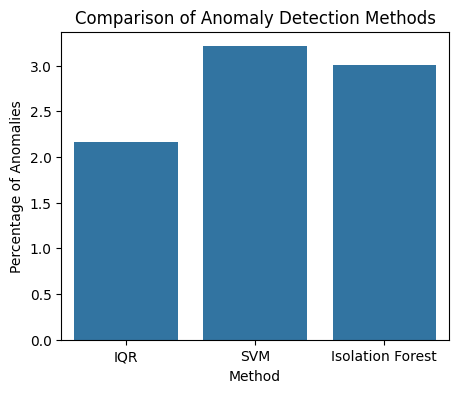

In [ ]:
if 'anomaly_svm' not in df_iqr.columns:
    df_iqr['anomaly_svm'] = y_svm

if 'anomaly_iso' not in df_iqr.columns:
    df_iqr['anomaly_iso'] = y_iso


# Create summary of anomaly counts
summary = pd.DataFrame({
    'Method': ['IQR', 'SVM', 'Isolation Forest'],
    'Anomaly Count': [
        df_iqr['anomaly_iqr'].sum(),
        df_iqr['anomaly_svm'].sum(),
        df_iqr['anomaly_iso'].sum()
    ]
})

# Calculate percentage
summary['Percentage'] = (summary['Anomaly Count'] / len(df_iqr)) * 100

print(summary, '\n')

# Where do the three methods overlap in anomaly detection
overlap = (
    (df_iqr['anomaly_iqr'] == 1) &
    (df_iqr['anomaly_svm'] == 1) &
    (df_iqr['anomaly_iso'] == 1)
).sum()

print(f"Detected by all three methods: {overlap}\n")


### Final Visualisation

# Bar plot comparison
plt.figure(figsize=(5,4))

sns.barplot(data=summary, x='Method', y='Percentage')

plt.title('Comparison of Anomaly Detection Methods')
plt.ylabel('Percentage of Anomalies')
plt.xlabel('Method')


plt.show()

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]